In [1]:
import copy
from pathlib import Path

import torch
import pandas as pd

from config_loader import load_unity_settings
from sim_core import CareSimulation
from rl_env import NurseDispatchEnv

print("Torch:", torch.__version__)
print("Current folder:", Path.cwd())

Torch: 2.5.1+cu121
Current folder: C:\Users\lny\Desktop\Research project\2D Caregiving Simulation\python_sim


In [2]:
class ActorCritic(torch.nn.Module):
    def __init__(self, observation_size, action_size):
        super().__init__()

        self.shared = torch.nn.Sequential(
            torch.nn.Linear(observation_size, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 128),
            torch.nn.ReLU()
        )

        self.actor = torch.nn.Linear(128, action_size)
        self.critic = torch.nn.Linear(128, 1)

    def forward(self, x):
        features = self.shared(x)
        logits = self.actor(features)
        value = self.critic(features)
        return logits, value

In [3]:
base_config = load_unity_settings()

env = NurseDispatchEnv(config=base_config)

model = ActorCritic(
    observation_size=env.observation_size,
    action_size=env.action_space_size
)

model_path = Path("outputs/ppo/ppo_v3_model.pt")

model.load_state_dict(torch.load(model_path, map_location="cpu"))
model.eval()

print("Loaded model:", model_path)
print("Observation size:", env.observation_size)
print("Action space size:", env.action_space_size)

Loaded model: outputs\ppo\ppo_v3_model.pt
Observation size: 20
Action space size: 5


C:\Users\lny\AppData\Local\Temp\ipykernel_58956\2792628336.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location="cp

In [4]:
def run_baseline(strategy, seed):
    config = copy.deepcopy(base_config)

    config["experiment"]["dispatch_mode"] = strategy
    config["experiment"]["random_seed"] = seed

    sim = CareSimulation(config)

    return sim.run()

In [5]:
def run_ppo(seed):
    env = NurseDispatchEnv(config=base_config)

    obs = env.reset(seed=seed)

    done = False
    final_info = {}

    while not done:
        obs_tensor = torch.tensor(
            obs,
            dtype=torch.float32
        ).unsqueeze(0)

        with torch.no_grad():
            logits, value = model(obs_tensor)

            action = torch.argmax(
                logits,
                dim=-1
            ).item()

        obs, reward, done, info = env.step(action)

        if done:
            final_info = info

    return final_info

In [6]:
ppo_result = run_ppo(seed=1)

print("Completed Tasks:", ppo_result["completed_tasks"])
print("Average Waiting Time:", ppo_result["average_waiting_time"] / 60)
print("Escalations:", ppo_result["escalations"])
print("Total Distance:", ppo_result["total_distance"])
print("Average Fatigue:", ppo_result["average_fatigue"])

Completed Tasks: 141
Average Waiting Time: 2.081323877068558
Escalations: 19
Total Distance: 8076.820353835702
Average Fatigue: 0.08521863537036697


In [7]:
strategies = [
    "fcfs",
    "shortest_distance",
    "priority_first",
    "ai_score"
]

seeds = list(range(1, 11))

evaluation_rows = []

for seed in seeds:
    for strategy in strategies:
        result = run_baseline(strategy, seed)

        evaluation_rows.append({
            "strategy": strategy,
            "seed": seed,
            "completed_tasks": result["completed_tasks"],
            "completion_rate": result["completion_rate"],
            "average_waiting_time_min": result["average_waiting_time"] / 60,
            "p95_waiting_time_min": result["p95_waiting_time"] / 60,
            "escalations": result["escalations"],
            "total_distance": result["total_distance"],
            "average_fatigue": result["average_fatigue"],
            "workload_std": result["workload_std"],
            "normal_workload_std": result["normal_workload_std"],
            "distance_std": result["distance_std"],
            "final_fatigue_std": result["final_fatigue_std"],
        })

        print(f"Done baseline: {strategy}, seed={seed}")

    result = run_ppo(seed)

    evaluation_rows.append({
        "strategy": "ppo",
        "seed": seed,
        "completed_tasks": result["completed_tasks"],
        "completion_rate": result["completion_rate"],
        "average_waiting_time_min": result["average_waiting_time"] / 60,
        "p95_waiting_time_min": result["p95_waiting_time"] / 60,
        "escalations": result["escalations"],
        "total_distance": result["total_distance"],
        "average_fatigue": result["average_fatigue"],
        "workload_std": result["workload_std"],
        "normal_workload_std": result["normal_workload_std"],
        "distance_std": result["distance_std"],
        "final_fatigue_std": result["final_fatigue_std"],
    })

    print(f"Done PPO, seed={seed}")

df_eval = pd.DataFrame(evaluation_rows)

df_eval.head()

Done baseline: fcfs, seed=1
Done baseline: shortest_distance, seed=1
Done baseline: priority_first, seed=1
Done baseline: ai_score, seed=1
Done PPO, seed=1
Done baseline: fcfs, seed=2
Done baseline: shortest_distance, seed=2
Done baseline: priority_first, seed=2
Done baseline: ai_score, seed=2
Done PPO, seed=2
Done baseline: fcfs, seed=3
Done baseline: shortest_distance, seed=3
Done baseline: priority_first, seed=3
Done baseline: ai_score, seed=3
Done PPO, seed=3
Done baseline: fcfs, seed=4
Done baseline: shortest_distance, seed=4
Done baseline: priority_first, seed=4
Done baseline: ai_score, seed=4
Done PPO, seed=4
Done baseline: fcfs, seed=5
Done baseline: shortest_distance, seed=5
Done baseline: priority_first, seed=5
Done baseline: ai_score, seed=5
Done PPO, seed=5
Done baseline: fcfs, seed=6
Done baseline: shortest_distance, seed=6
Done baseline: priority_first, seed=6
Done baseline: ai_score, seed=6
Done PPO, seed=6
Done baseline: fcfs, seed=7
Done baseline: shortest_distance, se

,strategy,seed,completed_tasks,completion_rate,average_waiting_time_min,p95_waiting_time_min,escalations,total_distance,average_fatigue,workload_std,normal_workload_std,distance_std,final_fatigue_std
0,fcfs,1,120,0.947368,6.226528,19.033333,126,10803.122965,0.321157,2.607681,2.190890,276.567369,0.085538
1,shortest_distance,1,166,0.994286,3.098896,8.916667,32,10227.198618,0.143721,2.529822,2.422120,149.659077,0.150398
2,priority_first,1,116,0.923664,8.059339,23.116667,131,10039.828399,0.373444,1.722401,1.366260,277.044910,0.059271
3,ai_score,1,151,0.981366,5.223731,11.900000,58,11543.140555,0.169515,1.366260,1.722401,79.796855,0.111072
4,ppo,1,141,0.915584,2.081324,7.933333,19,8076.820354,0.085219,3.834058,3.834058,145.108451,0.114608


In [8]:
output_dir = Path("outputs/ppo")
output_dir.mkdir(parents=True, exist_ok=True)

eval_path = output_dir / "ppo_v3_vs_baseline_results.csv"

df_eval.to_csv(eval_path, index=False)

print("Saved to:", eval_path)

Saved to: outputs\ppo\ppo_v3_vs_baseline_results.csv


In [9]:
summary_eval = (
    df_eval
    .groupby("strategy")
    .agg({
        "completed_tasks": ["mean", "std"],
        "completion_rate": ["mean", "std"],
        "average_waiting_time_min": ["mean", "std"],
        "p95_waiting_time_min": ["mean", "std"],
        "escalations": ["mean", "std"],
        "total_distance": ["mean", "std"],
        "average_fatigue": ["mean", "std"],
        "workload_std": ["mean", "std"],
        "normal_workload_std": ["mean", "std"],
        "distance_std": ["mean", "std"],
        "final_fatigue_std": ["mean", "std"],
    })
)

summary_eval

completed_tasks            completion_rate            \
                             mean        std            mean       std   
strategy                                                                 
ai_score                    161.0   7.972174        0.992287  0.006443   
fcfs                        127.0  10.903618        0.944879  0.035899   
ppo                         140.9   4.581363        0.909848  0.010403   
priority_first              121.0   7.483315        0.920693  0.027848   
shortest_distance           162.2   7.612855        0.991854  0.004713   

                  average_waiting_time_min           p95_waiting_time_min  \
                                      mean       std                 mean   
strategy                                                                    
ai_score                          3.454356  1.310264             9.841667   
fcfs                              6.287219  1.917026            18.451667   
ppo                               1.960441  0.752752             7.353333   
priority_first                    7.015121  1.490257            22.690000   
shortest_distance                 2.666903  0.824060             9.153333   

                            escalations             ... average_fatigue  \
                        std        mean        std  ...            mean   
strategy                                            ...                   
ai_score           1.465514        28.8  19.803479  ...        0.122690   
fcfs               5.979081       107.2  34.797190  ...        0.310245   
ppo                2.095259        17.2  11.073492  ...        0.085742   
priority_first     4.513821       126.8  20.980414  ...        0.346583   
shortest_distance  2.457576        29.0  10.143416  ...        0.145565   

                            workload_std           normal_workload_std  \
                        std         mean       std                mean   
strategy                                                                 
ai_score           0.055370     2.736889  0.790759            2.798998   
fcfs               0.046846     2.431191  0.818295            2.411690   
ppo                0.042133     3.442170  1.086006            3.442170   
priority_first     0.049512     1.790775  0.680244            1.857892   
shortest_distance  0.042434     3.194181  0.854535            3.146849   

                            distance_std            final_fatigue_std  \
                        std         mean        std              mean   
strategy                                                                
ai_score           0.749525   168.330182  59.830360          0.120251   
fcfs               0.748147   250.876075  96.940683          0.084120   
ppo                1.086006   198.100872  39.536090          0.121038   
priority_first     0.662408   207.358674  64.133071          0.076873   
shortest_distance  0.917326   208.255746  55.640253          0.154715   

                             
                        std  
strategy                     
ai_score           0.048338  
fcfs               0.027494  
ppo                0.051652  
priority_first     0.042690  
shortest_distance  0.040449  

[5 rows x 22 columns]

In [10]:
summary_flat = summary_eval.copy()
summary_flat.columns = [
    "_".join(col).strip()
    for col in summary_flat.columns.values
]
summary_flat = summary_flat.reset_index()

summary_flat["care_quality_score"] = (
    summary_flat["completion_rate_mean"] * 100
    - summary_flat["average_waiting_time_min_mean"] * 2
    - summary_flat["p95_waiting_time_min_mean"] * 1
    - summary_flat["escalations_mean"] * 0.5
    - summary_flat["average_fatigue_mean"] * 20
    - summary_flat["workload_std_mean"] * 2
    - summary_flat["distance_std_mean"] * 0.02
)

summary_flat

,strategy,completed_tasks_mean,completed_tasks_std,completion_rate_mean,completion_rate_std,average_waiting_time_min_mean,average_waiting_time_min_std,p95_waiting_time_min_mean,p95_waiting_time_min_std,escalations_mean,...,average_fatigue_std,workload_std_mean,workload_std_std,normal_workload_std_mean,normal_workload_std_std,distance_std_mean,distance_std_std,final_fatigue_std_mean,final_fatigue_std_std,care_quality_score
0,ai_score,161.0,7.972174,0.992287,0.006443,3.454356,1.310264,9.841667,1.465514,28.8,...,0.055370,2.736889,0.790759,2.798998,0.749525,168.330182,59.830360,0.120251,0.048338,56.784119
1,fcfs,127.0,10.903618,0.944879,0.035899,6.287219,1.917026,18.451667,5.979081,107.2,...,0.046846,2.431191,0.818295,2.411690,0.748147,250.876075,96.940683,0.084120,0.027494,-6.222987
2,ppo,140.9,4.581363,0.909848,0.010403,1.960441,0.752752,7.353333,2.095259,17.2,...,0.042133,3.442170,1.086006,3.442170,1.086006,198.100872,39.536090,0.121038,0.051652,58.549357
3,priority_first,121.0,7.483315,0.920693,0.027848,7.015121,1.490257,22.690000,4.513821,126.8,...,0.049512,1.790775,0.680244,1.857892,0.662408,207.358674,64.133071,0.076873,0.042690,-22.711341
4,shortest_distance,162.2,7.612855,0.991854,0.004713,2.666903,0.824060,9.153333,2.457576,29.0,...,0.042434,3.194181,0.854535,3.146849,0.917326,208.255746,55.640253,0.154715,0.040449,56.733444


In [11]:
output_dir = Path("outputs/ppo")
output_dir.mkdir(parents=True, exist_ok=True)

summary_path = output_dir / "ppo_v3_vs_baseline_summary.csv"

summary_flat.to_csv(summary_path, index=False)

print("Saved:", summary_path)

Saved: outputs\ppo\ppo_v3_vs_baseline_summary.csv


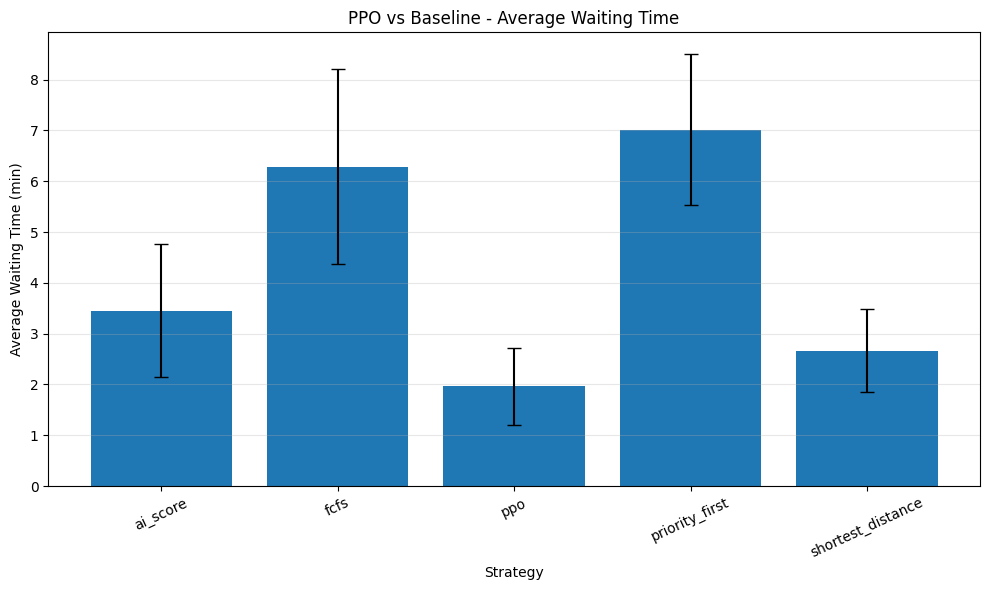

Saved: outputs\ppo\plots\ppo_vs_baseline_average_waiting_time.png


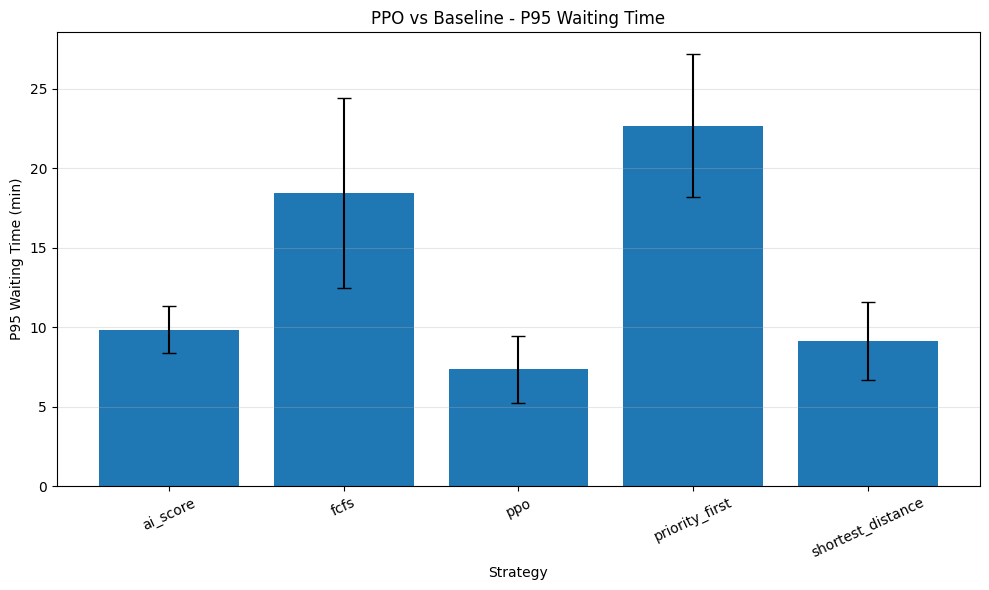

Saved: outputs\ppo\plots\ppo_vs_baseline_p95_waiting_time.png


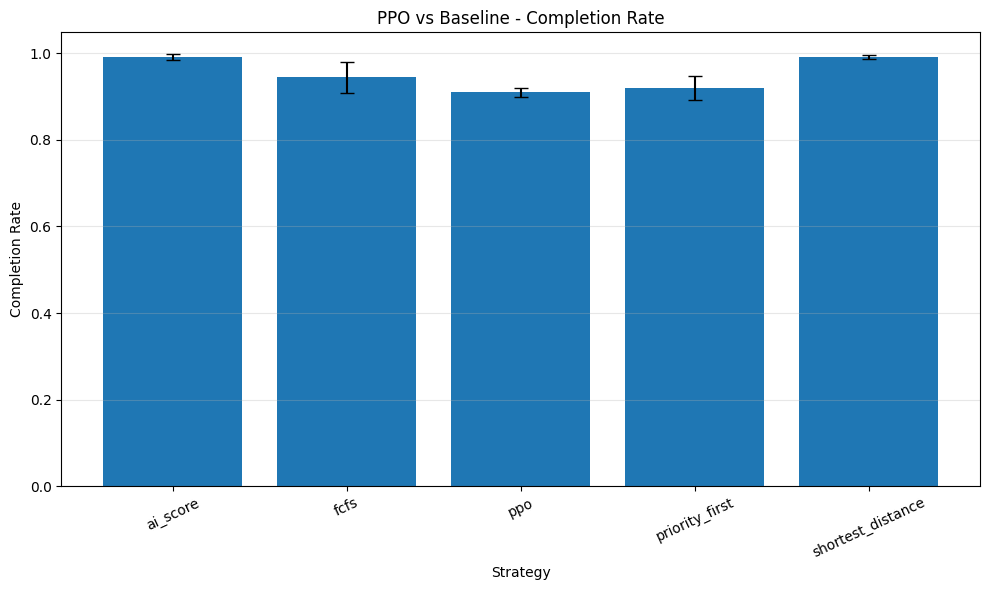

Saved: outputs\ppo\plots\ppo_vs_baseline_completion_rate.png


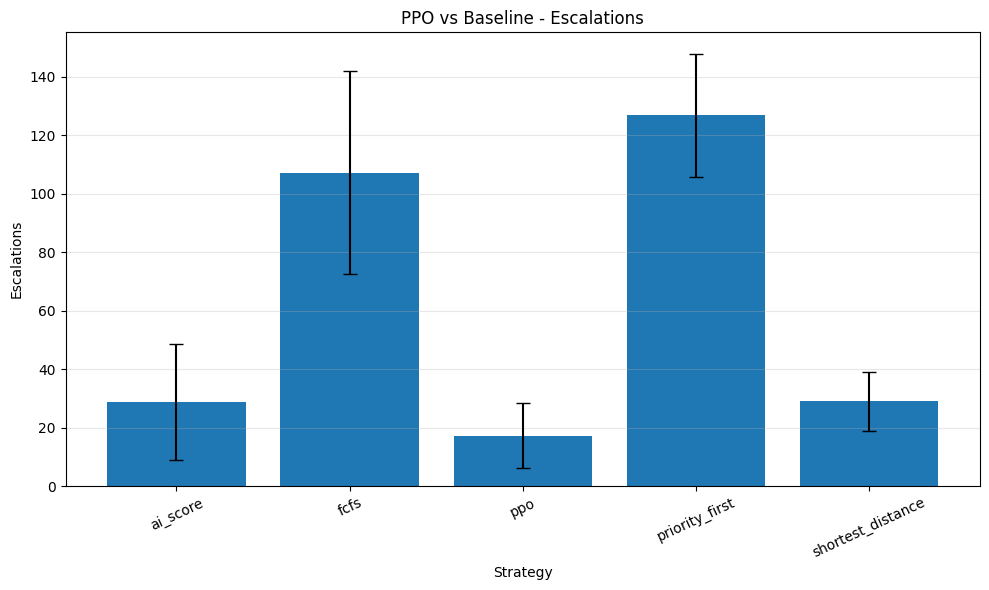

Saved: outputs\ppo\plots\ppo_vs_baseline_escalations.png


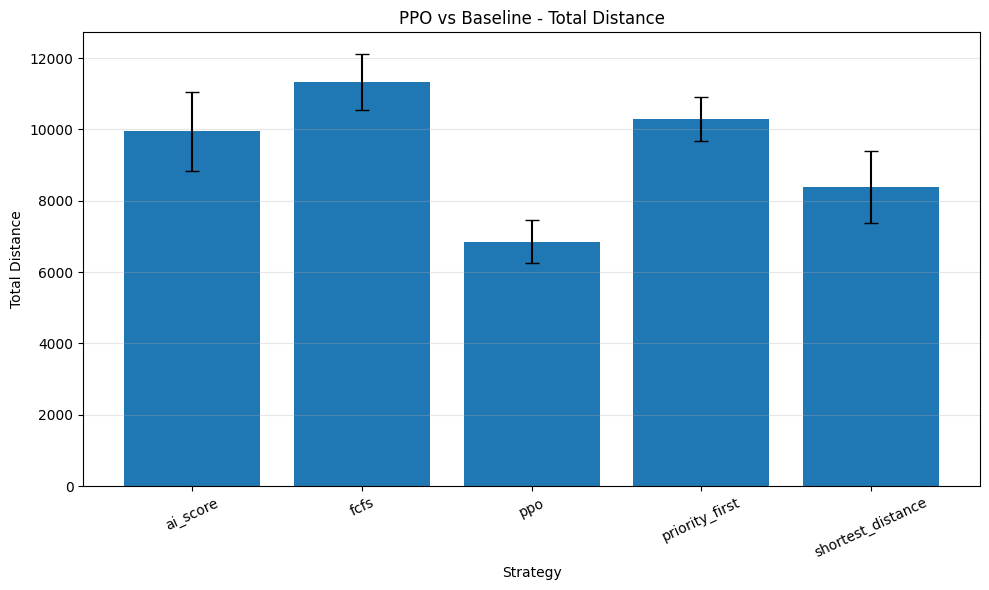

Saved: outputs\ppo\plots\ppo_vs_baseline_total_distance.png


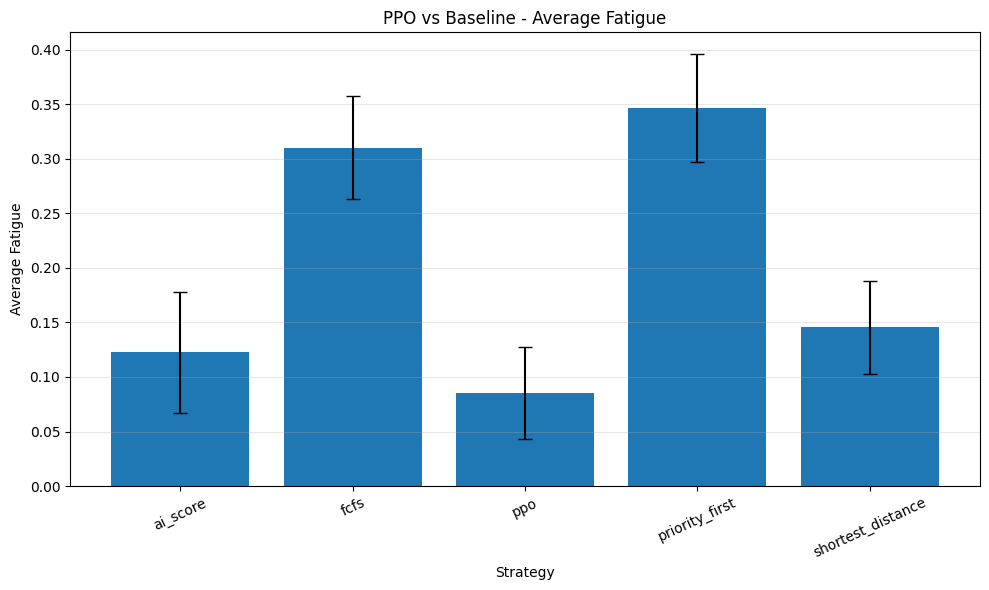

Saved: outputs\ppo\plots\ppo_vs_baseline_average_fatigue.png


In [12]:
import matplotlib.pyplot as plt
plot_dir = Path("outputs/ppo/plots")
plot_dir.mkdir(parents=True, exist_ok=True)

def plot_eval_bar(metric_mean, metric_std, title, ylabel, filename):
    plt.figure(figsize=(10, 6))

    plt.bar(
        summary_flat["strategy"],
        summary_flat[metric_mean],
        yerr=summary_flat[metric_std],
        capsize=5
    )

    plt.xlabel("Strategy")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=25)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    save_path = plot_dir / filename
    plt.savefig(save_path, dpi=300)
    plt.show()

    print("Saved:", save_path)


plot_eval_bar(
    "average_waiting_time_min_mean",
    "average_waiting_time_min_std",
    "PPO vs Baseline - Average Waiting Time",
    "Average Waiting Time (min)",
    "ppo_vs_baseline_average_waiting_time.png"
)

plot_eval_bar(
    "p95_waiting_time_min_mean",
    "p95_waiting_time_min_std",
    "PPO vs Baseline - P95 Waiting Time",
    "P95 Waiting Time (min)",
    "ppo_vs_baseline_p95_waiting_time.png"
)

plot_eval_bar(
    "completion_rate_mean",
    "completion_rate_std",
    "PPO vs Baseline - Completion Rate",
    "Completion Rate",
    "ppo_vs_baseline_completion_rate.png"
)

plot_eval_bar(
    "escalations_mean",
    "escalations_std",
    "PPO vs Baseline - Escalations",
    "Escalations",
    "ppo_vs_baseline_escalations.png"
)

plot_eval_bar(
    "total_distance_mean",
    "total_distance_std",
    "PPO vs Baseline - Total Distance",
    "Total Distance",
    "ppo_vs_baseline_total_distance.png"
)

plot_eval_bar(
    "average_fatigue_mean",
    "average_fatigue_std",
    "PPO vs Baseline - Average Fatigue",
    "Average Fatigue",
    "ppo_vs_baseline_average_fatigue.png"
)